In [8]:
import pandas as pd
train = pd.read_csv('./data/train.csv')
TARGETS = ['time_to_hit_hours', 'event']
FEATURES = [col for col in train.columns if col not in TARGETS + ['event_id', 'log1p_area_first']]
full_train_data = train[TARGETS + FEATURES].copy()

In [9]:
import numpy as np
from sklearn.model_selection import KFold
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from sksurv.metrics import brier_score
from sksurv.util import Surv

HORIZONS = [24, 48, 72]
HORIZON_WEIGHTS = [0.3, 0.4, 0.3]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(full_train_data)):
    train_fold = full_train_data.iloc[train_idx]
    val_fold = full_train_data.iloc[val_idx]

    # Fit model
    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(train_fold, duration_col='time_to_hit_hours', event_col='event')

    # --- C-index ---
    c_idx = concordance_index(
        val_fold['time_to_hit_hours'],
        -cph.predict_partial_hazard(val_fold),
        val_fold['event']
    )

    # --- Brier Score at each horizon ---
    # sksurv needs structured arrays
    train_surv = Surv.from_arrays(
        event=train_fold['event'].astype(bool),
        time=train_fold['time_to_hit_hours']
    )
    val_surv = Surv.from_arrays(
        event=val_fold['event'].astype(bool),
        time=val_fold['time_to_hit_hours']
    )

    # Get survival probabilities at each horizon
    surv_funcs = cph.predict_survival_function(val_fold)

    brier_scores = []
    for h, w in zip(HORIZONS, HORIZON_WEIGHTS):
        # Only evaluate at horizons within the observed time range
        max_time = val_fold['time_to_hit_hours'].max()

        if h > max_time:
            print(f"Skipping horizon {h}h (exceeds max validation time {max_time:.2f}h)")
            continue

        # Extract predicted probability of event by horizon h
        # = 1 - S(h)
        pred_probs = 1 - cph.predict_survival_function(val_fold, times=[h]).values.flatten()

        _, bs = brier_score(train_surv, val_surv, pred_probs, [h])

        brier_scores.append((h, w, bs[0]))

    # Weighted Brier
    total_weight = sum(w for _, w, _ in brier_scores)
    weighted_brier = sum(w * bs for _, w, bs in brier_scores) / total_weight

    # Hybrid score
    hybrid = 0.3 * c_idx + 0.7 * (1 - weighted_brier)

    fold_scores.append({
        'fold': fold + 1,
        'c_index': c_idx,
        **{f'brier_{h}h': bs for h, _, bs in brier_scores},
        'weighted_brier': weighted_brier,
        'hybrid': hybrid
    })

    print(f"Fold {fold+1}: C-index={c_idx:.3f} | "
          + " | ".join(f"Brier@{h}h={bs:.3f}" for h, _, bs in brier_scores)
          + f" | Weighted Brier={weighted_brier:.3f} | Hybrid={hybrid:.3f}")

# Summary
print("\n" + "="*60)
print("CROSS-VALIDATION SUMMARY")
print("="*60)
for metric in ['c_index', 'brier_24h', 'brier_48h', 'brier_72h', 'weighted_brier', 'hybrid']:
    vals = [f[metric] for f in fold_scores if metric in f]
    print(f"{metric:20s}: {np.mean(vals):.3f} ± {np.std(vals):.3f}")

Skipping horizon 72h (exceeds max validation time 66.66h)
Fold 1: C-index=0.820 | Brier@24h=0.528 | Brier@48h=0.542 | Weighted Brier=0.536 | Hybrid=0.571
Skipping horizon 72h (exceeds max validation time 66.79h)
Fold 2: C-index=0.912 | Brier@24h=0.584 | Brier@48h=0.621 | Weighted Brier=0.605 | Hybrid=0.550
Skipping horizon 72h (exceeds max validation time 66.97h)
Fold 3: C-index=0.769 | Brier@24h=0.568 | Brier@48h=0.576 | Weighted Brier=0.573 | Hybrid=0.530
Skipping horizon 72h (exceeds max validation time 66.92h)
Fold 4: C-index=0.866 | Brier@24h=0.620 | Brier@48h=0.613 | Weighted Brier=0.616 | Hybrid=0.528
Skipping horizon 72h (exceeds max validation time 66.99h)
Fold 5: C-index=0.898 | Brier@24h=0.560 | Brier@48h=0.493 | Weighted Brier=0.521 | Hybrid=0.604

CROSS-VALIDATION SUMMARY
c_index             : 0.853 ± 0.053
brier_24h           : 0.572 ± 0.030
brier_48h           : 0.569 ± 0.047
brier_72h           : nan ± nan
weighted_brier      : 0.570 ± 0.037
hybrid              : 0.557 

C:\Users\aydin\miniconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\aydin\miniconda3\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\aydin\miniconda3\Lib\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\aydin\miniconda3\Lib\site-packages\numpy\_core\_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\aydin\miniconda3\Lib\site-packages\numpy\_core\_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [10]:
# Fit model on FULL training data
cph_full = CoxPHFitter(penalizer=0.1)
cph_full.fit(full_train_data, duration_col='time_to_hit_hours', event_col='event')

<lifelines.CoxPHFitter: fitted with 221 total observations, 152 right-censored observations>

Mean predicted probability of event by 48h: 0.340
25th percentile: 0.130
50th percentile (median): 0.281
75th percentile: 0.397
90th percentile: 0.789


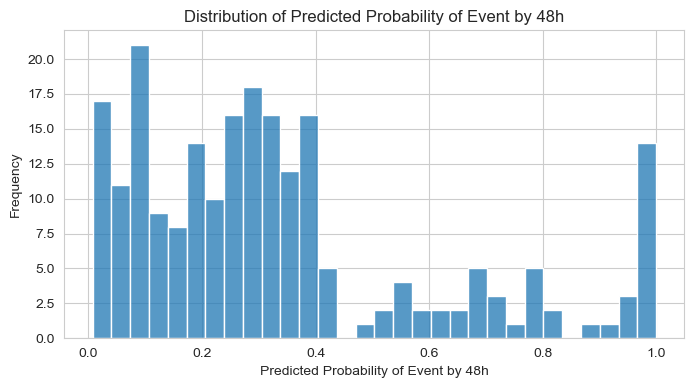

In [11]:
# Get predicted probability of event by 48h for full training data
pred_probs_48 = 1 - cph_full.predict_survival_function(full_train_data, times=[48]).values.flatten()
# print the mean, quartiles, 75th and 90th percentiles of the predicted probabilities
print(f"Mean predicted probability of event by 48h: {pred_probs_48.mean():.3f}")
print(f"25th percentile: {np.percentile(pred_probs_48, 25):.3f}")
print(f"50th percentile (median): {np.percentile(pred_probs_48, 50):.3f}")
print(f"75th percentile: {np.percentile(pred_probs_48, 75):.3f}")
print(f"90th percentile: {np.percentile(pred_probs_48, 90):.3f}")
# plot the distribution of the continuous variable 'pred_probs_48'
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 4))
sns.histplot(pred_probs_48, bins=30)
plt.title('Distribution of Predicted Probability of Event by 48h')
plt.xlabel('Predicted Probability of Event by 48h')
plt.ylabel('Frequency')
plt.show()

In [ ]:
pred_probs_72 = 1 - cph_full.predict_survival_function(full_train_data, times=[72]).values.flatten()
print(pd.Series(pred_probs_72).describe())
plt.figure(figsize=(8, 4))
sns.histplot(pred_probs_72, bins=30)
plt.title('Distribution of Predicted Probability of Event by 72h')
plt.xlabel('Predicted Probability of Event by 72h')
plt.ylabel('Frequency')
plt.show()

In [17]:
# Display Cox model feature importance
print("="*80)
print("COX MODEL FEATURE IMPORTANCE")
print("="*80)
print(cph_full.summary)

print("\n" + "="*80)
print("TOP 15 FEATURES BY ABSOLUTE COEFFICIENT MAGNITUDE")
print("="*80)
feature_importance = cph_full.summary[['coef', 'exp(coef)', 'p']].copy()
feature_importance['abs_coef'] = feature_importance['coef'].abs()
feature_importance_sorted = feature_importance.sort_values('abs_coef', ascending=False)
print(feature_importance_sorted.head(15))

print(f"\n{'='*80}")
print(f"Significant features (p < 0.05): {(feature_importance['p'] < 0.05).sum()}/{len(feature_importance)}")
print(f"Marginally significant (0.05 ≤ p < 0.10): {((feature_importance['p'] >= 0.05) & (feature_importance['p'] < 0.10)).sum()}/{len(feature_importance)}")
print(f"Not significant (p ≥ 0.10): {(feature_importance['p'] >= 0.10).sum()}/{len(feature_importance)}")

COX MODEL FEATURE IMPORTANCE
                                  coef  exp(coef)      se(coef)  \
covariate                                                         
num_perimeters_0_5h           0.097630   1.102555  5.841784e-02   
dt_first_last_0_5h            0.021597   1.021832  8.856417e-02   
low_temporal_resolution_0_5h -0.324712   0.722736  3.556698e-01   
area_first_ha                -0.000150   0.999850  1.077273e-04   
area_growth_abs_0_5h         -0.000101   0.999899  1.003086e-03   
area_growth_rel_0_5h          0.019070   1.019253  1.405367e-01   
area_growth_rate_ha_per_h    -0.000082   0.999918  4.693629e-03   
log1p_growth                  0.149625   1.161399  1.241596e-01   
log_area_ratio_0_5h          -0.270010   0.763372  5.941531e-01   
relative_growth_0_5h          0.019070   1.019253  1.405367e-01   
radial_growth_m              -0.000108   0.999892  1.347402e-03   
radial_growth_rate_m_per_h    0.000340   1.000340  5.136420e-03   
centroid_displacement_m      -0.0

In [ ]:
# Load test data and generate predictions for submission
test = pd.read_csv('./data/test.csv')

# Check max observed time in training data
max_observed = train['time_to_hit_hours'].max()
print(f"Max observed time in training data: {max_observed:.2f}h")

# Prepare test data with same features
test_features = test[FEATURES].copy()

# Generate predictions at all required horizons (12h, 24h, 48h, 72h)
submission_horizons = [12, 24, 48, 72]
predictions = {'event_id': test['event_id']}

for h in submission_horizons:
    if h > max_observed:
        print(f"⚠️ WARNING: Predicting at {h}h but max observed time is {max_observed:.2f}h (extrapolation)")

    # Predict probability of event by horizon h
    pred_probs = 1 - cph_full.predict_survival_function(test_features, times=[h]).values.flatten()
    predictions[f'prob_{h}h'] = pred_probs

    print(f"Predictions at {h}h: mean={pred_probs.mean():.3f}, min={pred_probs.min():.3f}, max={pred_probs.max():.3f}")

# Create submission dataframe
submission = pd.DataFrame(predictions)

# Save to CSV
submission.to_csv('test_submission.csv', index=False)
print(f"\n✓ Submission saved to 'test_submission.csv'")
print(f"  Shape: {submission.shape}")
print(f"\nFirst few rows:")
print(submission.head())

In [18]:
def evaluate_custom_features(feature_list, data, feature_name="Custom Features"):
    """
    Run 5-fold cross-validation on CPH model with specified features.

    Parameters:
    -----------
    feature_list : list
        List of feature column names to use
    data : pd.DataFrame
        Full training data (must contain TARGETS columns)
    feature_name : str
        Name for printing/logging purposes

    Returns:
    --------
    list : fold_scores with CV results
    """
    print("="*80)
    print(f"CROSS-VALIDATION: {feature_name}")
    print(f"Features: {len(feature_list)}")
    print("="*80)

    # Create dataset with specified features
    data_subset = data[TARGETS + feature_list].copy()

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores_custom = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(data_subset)):
        train_fold = data_subset.iloc[train_idx]
        val_fold = data_subset.iloc[val_idx]

        # Fit model
        cph = CoxPHFitter(penalizer=0.1)
        cph.fit(train_fold, duration_col='time_to_hit_hours', event_col='event')

        # --- C-index ---
        c_idx = concordance_index(
            val_fold['time_to_hit_hours'],
            -cph.predict_partial_hazard(val_fold),
            val_fold['event']
        )

        # --- Brier Score at each horizon ---
        train_surv = Surv.from_arrays(
            event=train_fold['event'].astype(bool),
            time=train_fold['time_to_hit_hours']
        )
        val_surv = Surv.from_arrays(
            event=val_fold['event'].astype(bool),
            time=val_fold['time_to_hit_hours']
        )

        brier_scores = []
        for h, w in zip(HORIZONS, HORIZON_WEIGHTS):
            max_time = val_fold['time_to_hit_hours'].max()

            if h > max_time:
                continue

            pred_probs = 1 - cph.predict_survival_function(val_fold, times=[h]).values.flatten()
            _, bs = brier_score(train_surv, val_surv, pred_probs, [h])
            brier_scores.append((h, w, bs[0]))

        # Weighted Brier
        total_weight = sum(w for _, w, _ in brier_scores)
        weighted_brier = sum(w * bs for _, w, bs in brier_scores) / total_weight

        # Hybrid score
        hybrid = 0.3 * c_idx + 0.7 * (1 - weighted_brier)

        fold_scores_custom.append({
            'fold': fold + 1,
            'c_index': c_idx,
            **{f'brier_{h}h': bs for h, _, bs in brier_scores},
            'weighted_brier': weighted_brier,
            'hybrid': hybrid
        })

        print(f"Fold {fold+1}: C-index={c_idx:.3f} | "
              + " | ".join(f"Brier@{h}h={bs:.3f}" for h, _, bs in brier_scores)
              + f" | Weighted Brier={weighted_brier:.3f} | Hybrid={hybrid:.3f}")

    # Summary
    print("\n" + "="*80)
    print(f"CROSS-VALIDATION SUMMARY - {feature_name}")
    print("="*80)
    for metric in ['c_index', 'brier_24h', 'brier_48h', 'brier_72h', 'weighted_brier', 'hybrid']:
        vals = [f[metric] for f in fold_scores_custom if metric in f]
        if vals:
            print(f"{metric:20s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

    return fold_scores_custom


def train_and_submit(feature_list, data, test_data, filename_suffix=""):
    """
    Train CPH model on full dataset with specified features and generate test submission.

    Parameters:
    -----------
    feature_list : list
        List of feature column names to use
    data : pd.DataFrame
        Full training data (must contain TARGETS columns)
    test_data : pd.DataFrame
        Test data
    filename_suffix : str
        Suffix for submission filename (e.g., "_significant" creates "test_submission_significant.csv")

    Returns:
    --------
    tuple : (cph_model, submission_df)
    """
    print("="*80)
    print(f"TRAINING MODEL ON FULL DATASET")
    print(f"Features: {len(feature_list)}")
    print("="*80)

    # Fit model on full training data
    data_subset = data[TARGETS + feature_list].copy()
    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(data_subset, duration_col='time_to_hit_hours', event_col='event')

    print("\nModel trained successfully!")

    # Prepare test data with same features
    test_features = test_data[feature_list].copy()

    # Generate predictions at all required horizons (12h, 24h, 48h, 72h)
    submission_horizons = [12, 24, 48, 72]
    predictions = {'event_id': test_data['event_id']}

    max_observed = data['time_to_hit_hours'].max()

    for h in submission_horizons:
        if h > max_observed:
            print(f"⚠️  WARNING: Predicting at {h}h but max observed time is {max_observed:.2f}h (extrapolation)")

        # Predict probability of event by horizon h
        pred_probs = 1 - cph.predict_survival_function(test_features, times=[h]).values.flatten()
        predictions[f'prob_{h}h'] = pred_probs

        print(f"Predictions at {h}h: mean={pred_probs.mean():.3f}, min={pred_probs.min():.3f}, max={pred_probs.max():.3f}")

    # Create submission dataframe
    submission = pd.DataFrame(predictions)

    # Save to CSV
    filename = f'test_submission{filename_suffix}.csv'
    submission.to_csv(filename, index=False)
    print(f"\n✓ Submission saved to '{filename}'")
    print(f"  Shape: {submission.shape}")
    print(f"\nFirst few rows:")
    print(submission.head())

    return cph, submission


In [19]:
# Extract significant features (p < 0.1) from the baseline model
SIGNIFICANT_FEATURES = feature_importance[feature_importance['p'] < 0.1].index.tolist()

print("="*80)
print("SIGNIFICANT FEATURES (p < 0.1)")
print("="*80)
print(f"Count: {len(SIGNIFICANT_FEATURES)}")
print(f"Features: {SIGNIFICANT_FEATURES}")
print()

# Run cross-validation with significant features only
fold_scores_significant = evaluate_custom_features(
    SIGNIFICANT_FEATURES,
    full_train_data,
    feature_name="Significant Features (p < 0.1)"
)

# Compare with baseline
print("\n" + "="*80)
print("COMPARISON: ALL FEATURES vs SIGNIFICANT ONLY")
print("="*80)
print(f"{'Metric':<25} {'All Features':<20} {'Significant Only':<20} {'Difference':<15}")
print("-" * 80)
for metric in ['c_index', 'brier_24h', 'brier_48h', 'brier_72h', 'weighted_brier', 'hybrid']:
    all_vals = [f[metric] for f in fold_scores if metric in f]
    sig_vals = [f[metric] for f in fold_scores_significant if metric in f]
    if all_vals and sig_vals:
        all_mean = np.mean(all_vals)
        sig_mean = np.mean(sig_vals)
        diff = sig_mean - all_mean
        print(f"{metric:<25} {all_mean:<20.4f} {sig_mean:<20.4f} {diff:+.4f}")

print("\n")

# Generate test submission with significant features only
cph_significant, submission_significant = train_and_submit(
    SIGNIFICANT_FEATURES,
    full_train_data,
    test,
    filename_suffix="_significant"
)


SIGNIFICANT FEATURES (p < 0.1)
Count: 3
Features: ['num_perimeters_0_5h', 'dist_min_ci_0_5h', 'cross_track_component']

CROSS-VALIDATION: Significant Features (p < 0.1)
Features: 3
Fold 1: C-index=0.924 | Brier@24h=0.548 | Brier@48h=0.543 | Weighted Brier=0.545 | Hybrid=0.596
Fold 2: C-index=0.947 | Brier@24h=0.497 | Brier@48h=0.519 | Weighted Brier=0.510 | Hybrid=0.627
Fold 3: C-index=0.835 | Brier@24h=0.529 | Brier@48h=0.553 | Weighted Brier=0.543 | Hybrid=0.570
Fold 4: C-index=0.907 | Brier@24h=0.545 | Brier@48h=0.525 | Weighted Brier=0.533 | Hybrid=0.599
Fold 5: C-index=0.940 | Brier@24h=0.508 | Brier@48h=0.457 | Weighted Brier=0.479 | Hybrid=0.647

CROSS-VALIDATION SUMMARY - Significant Features (p < 0.1)
c_index             : 0.9106 ± 0.0403
brier_24h           : 0.5255 ± 0.0201
brier_48h           : 0.5196 ± 0.0336
weighted_brier      : 0.5221 ± 0.0251
hybrid              : 0.6077 ± 0.0266

COMPARISON: ALL FEATURES vs SIGNIFICANT ONLY
Metric                    All Features      